In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append("..")  # not needed if phonespam is pip-installed
from phonespam import PhoneModel


In [2]:
model = PhoneModel.from_pretrained("juice500/wavlm-24-phonemodel")

In [3]:
wav = model.load_audio("plots/LDC93S1.wav")[500:6000]  # "she"
feats = model.extract_features(wav)
spam = model.spam_from_features(feats)
boundaries, signal = model.segmenter.with_hparams({
    "combined_signals": [{"name": "frame_delta", "kwargs": {"offset": 1}, "shift": 0}],
}).segment(feats, wav, return_signal=True)
triples = model.recognizer.recognize(
    spam,
    boundaries=model.encoder.frame_to_time(np.arange(len(spam))),
    sr=model.sr,
    frame_shift=model.frame_shift,
    vocab=pd.read_csv("../data/timit-merged.csv").ipa.unique(),
)


phonespam/recognizer.py:320: UserWarning: Ignoring 1 phone(s) with segment(s) not recognized by panphon for user-supplied vocab: ['_']
  return _validate_vocab(tuple(vocab))


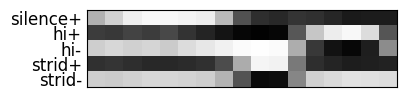

In [50]:
WANTED = ["silence+", "hi+", "hi-", "strid+", "strid-"]
heat = np.asarray(spam.select(WANTED)).T

fig, ax = plt.subplots(1, 1, figsize=(4, 1))
im = ax.imshow(heat, aspect="auto", cmap="gray", vmin=0, vmax=1, extent=[0, len(wav)/16000, len(WANTED)-0.5, -0.5])
ax.set_yticks(range(len(WANTED)))
ax.set_yticklabels(WANTED, fontsize=12)
ax.tick_params(axis="y", length=0)
# ax.set_xlabel("Time (s)")
# ax.set_ylabel("SPAM", fontsize=15, fontweight="bold")


edges = (np.arange(heat.shape[1])+1) / heat.shape[1] * len(wav) / 16000 - 0.001
# ax.set_xticks(edges, minor=True)
ax.set_xticks([])
ax.grid(which="minor", axis="x", color="gray", linewidth=0.5, alpha=0.5)
ax.tick_params(which="minor", length=0)

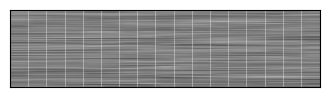

In [41]:
heat = np.asarray(feats).T

fig, ax = plt.subplots(1, 1, figsize=(4, 1))
im = ax.imshow(feats.T, aspect="auto", cmap="gray", vmin=-0.5, vmax=0.5, extent=[0, len(wav)/16000, len(WANTED)-0.5, -0.5])
# ax.set_xlabel("Time (s)")
ax.set_yticks([])

# ax.set_ylabel("S3M\nFeat.", fontsize=15, fontweight="bold")
ax.set_xticks([])


edges = np.arange(heat.shape[1]) / heat.shape[1] * len(wav) / 16000 - 0.001
ax.set_xticks(edges, minor=True)
ax.grid(which="minor", axis="x", color="white", linewidth=0.5, alpha=0.5)
ax.tick_params(which="minor", length=0)

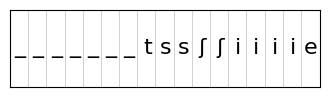

In [47]:
recog_list = []
for start, end, ipa in triples:
    recog_list += [ipa] * (end - start)

fig, ax = plt.subplots(1, 1, figsize=(4, 1))
ax.set_yticks([])
ax.set_xticks([])
# ax.set_ylabel("IPA", fontsize=15, fontweight="bold")

# im = ax.imshow(heat, aspect="auto", cmap="gray", vmin=0, vmax=1, extent=[0, len(wav)/16000, len(WANTED)-0.5, -0.5])
ax.tick_params(axis="y", length=0)
# ax.set_xlabel("Time (s)")
ax.set_xlim(0, len(wav) / 16000)

block_width = (len(wav) / 16000) / heat.shape[1]
trans = ax.get_xaxis_transform()
for i, ipa in enumerate(recog_list):
    x_center = (i + 0.5) * block_width
    ax.text(x_center, 0.5, ipa, ha="center", va="center", transform=trans, fontsize=16)

ax.set_xticks(edges, minor=True)
ax.grid(which="minor", axis="x", color="gray", linewidth=0.5, alpha=0.5)
ax.tick_params(which="minor", length=0)

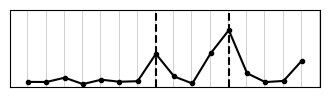

In [53]:
fig, ax = plt.subplots(1, 1, figsize=(4, 1))

ax.tick_params(axis="y", length=0)
# ax.set_xlabel("Time (s)")
# ax.set_ylabel("Δ SPAM", fontsize=15, fontweight="bold")
ax.set_xlim(0, len(wav) / 16000)
ax.set_ylim(0-0.01, 0.4+0.01)
# ax.set_yticks([0, 0.2, 0.4])
ax.set_yticks([])
ax.set_xticks([])

x = (1 + np.arange(heat.shape[1])) / heat.shape[1] * len(wav) / 16000
ax.plot(x, signal, ".-", c="black")
for xloc in x[boundaries]:
    ax.axvline(xloc, linestyle="--", c="black")

ax.set_xticks(edges, minor=True)
ax.grid(which="minor", axis="x", color="gray", linewidth=0.5, alpha=0.5)
ax.tick_params(which="minor", length=0)

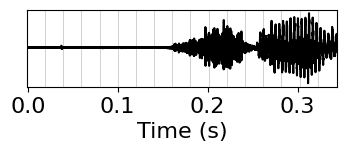

In [46]:
fig, ax = plt.subplots(1, 1, figsize=(4, 1))

ax.tick_params(axis="y", length=0)
ax.set_xlabel("Time (s)", fontsize=16)
ax.set_xticks([0, 0.1, 0.2, 0.3], labels=['0.0', '0.1', '0.2', '0.3'], fontsize=16)

# ax.set_ylabel("Audio", fontsize=15, fontweight="bold")
ax.set_yticks([])
ax.set_xlim(0, len(wav) / 16000)
# ax.set_ylim(0-0.01, 0.4+0.01)

x = np.arange(len(wav)) / 16000
ax.plot(x, wav, "-", c="black")
# for xloc in x[boundaries]:
#     ax.axvline(xloc, linestyle="--", c="black")

ax.set_xticks(edges, minor=True)
ax.grid(which="minor", axis="x", color="gray", linewidth=0.5, alpha=0.5)
ax.tick_params(which="minor", length=0)